# Faraday Rotation Results

Simulation results at 10, 30, 50 MHz with and without Faraday rotation.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator, NullFormatter
from lunarsky import Time

# ——— Data ———
RES_DIR = Path("results")
sims = {}
for freq in [10, 30, 50]:
    sims[freq] = dict(np.load(RES_DIR / f"faraday_sim_{freq}mhz.npz"))

times_jd = sims[10]["times_jd"]
times_dt = [Time(jd, format="jd").to_datetime() for jd in times_jd]

# ——— Colors (Paul Tol Bright) ———
BLUE = "#4477AA"
RED = "#EE6677"

# ——— Journal rcParams ———
mpl.rcParams.update({
    "figure.dpi": 200,
    "font.size": 8,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.size": 1.5,
    "ytick.minor.size": 1.5,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
})

## Plot 1 — Stokes I, Q, U Waterfall at 30 MHz

Frequency vs time for no-FR (top) and FR (bottom). Zoom-bin resolution.

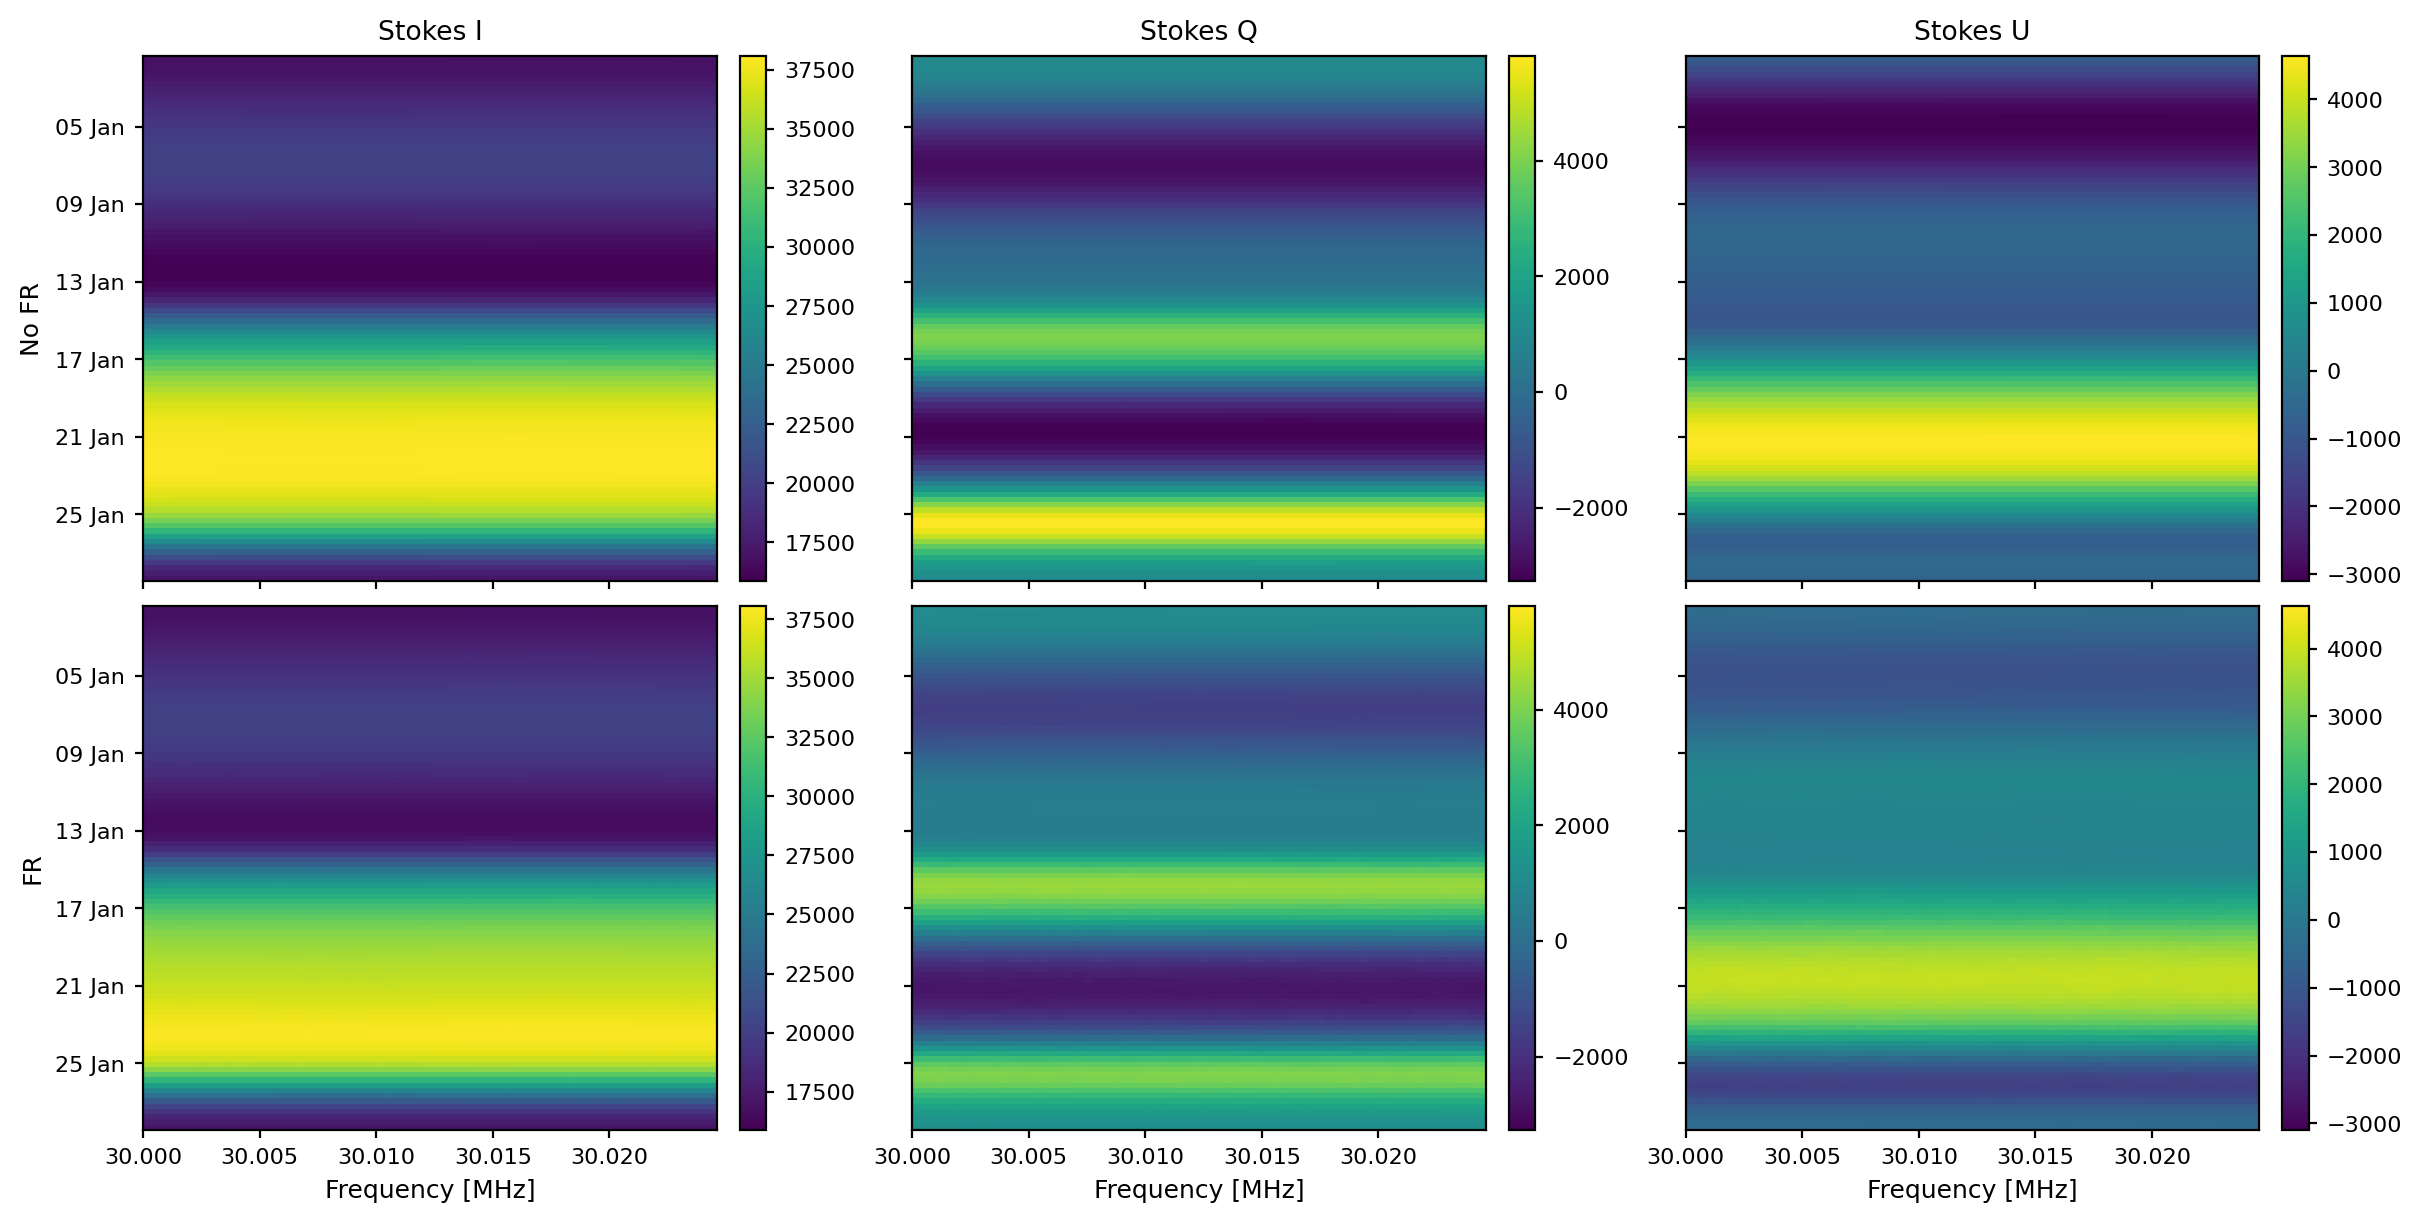

In [2]:
d = sims[30]
fz = d["freqs_zoom"]
extent = [fz[0], fz[-1], mdates.date2num(times_dt[-1]), mdates.date2num(times_dt[0])]

stokes = ["I", "Q", "U"]
rows = ["noFR", "FR"]
row_labels = ["No FR", "FR"]

fig, axs = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)

for col, s in enumerate(stokes):
    arr_noFR = d[f"p{s}_noFR_zoom"]
    arr_FR = d[f"p{s}_FR_zoom"]
    vmin = min(arr_noFR.min(), arr_FR.min())
    vmax = max(arr_noFR.max(), arr_FR.max())
    for row, (tag, label) in enumerate(zip(rows, row_labels)):
        ax = axs[row, col]
        arr = arr_noFR if tag == "noFR" else arr_FR
        im = ax.imshow(arr, aspect="auto", extent=extent, vmin=vmin, vmax=vmax)
        ax.yaxis_date()
        ax.yaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        if row == 0:
            ax.set_title(f"Stokes {s}")
        if col == 0:
            ax.set_ylabel(label)
        else:
            ax.set_yticklabels([])
        if row == 1:
            ax.set_xlabel("Frequency [MHz]")
        else:
            ax.set_xticklabels([])

plt.show()

## Plot 2 — Delay Spectrum Q & U at 10, 30, 50 MHz

Single galaxy-up snapshot (time index 81) at all three frequencies.

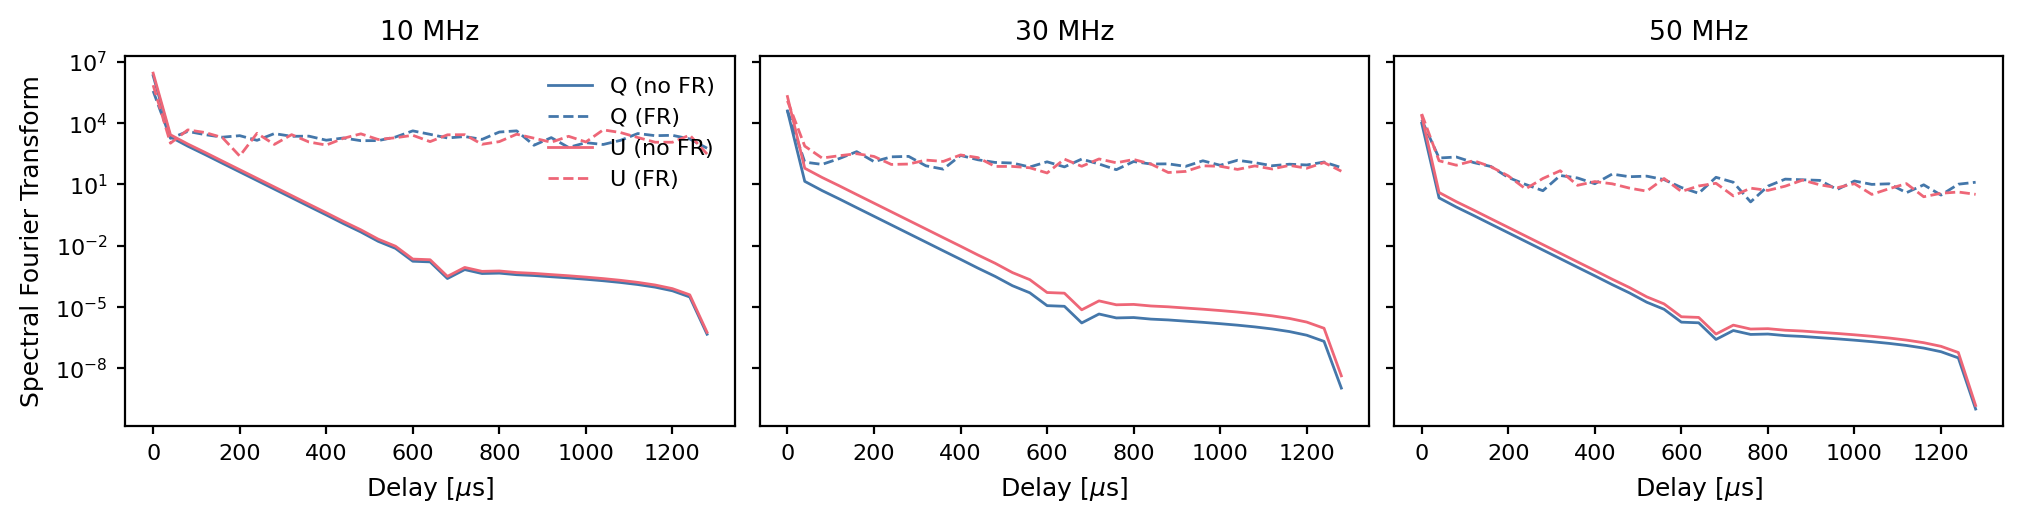

In [3]:
I_GAL = 81  # common time index for all three frequencies

fig, axs = plt.subplots(1, 3, figsize=(10, 2.5), constrained_layout=True,
                         sharey=True)

for i, freq in enumerate([10, 30, 50]):
    ax = axs[i]
    d = sims[freq]
    fz = d["freqs_zoom"]
    df = fz[1] - fz[0]
    tau = np.fft.rfftfreq(64, d=df)  # in microseconds

    Q_noFR = d["pQ_noFR_zoom"][I_GAL]
    Q_FR = d["pQ_FR_zoom"][I_GAL]
    U_noFR = d["pU_noFR_zoom"][I_GAL]
    U_FR = d["pU_FR_zoom"][I_GAL]

    ft_Q_noFR = np.abs(np.fft.rfft(Q_noFR))
    ft_Q_FR = np.abs(np.fft.rfft(Q_FR))
    ft_U_noFR = np.abs(np.fft.rfft(U_noFR))
    ft_U_FR = np.abs(np.fft.rfft(U_FR))

    ax.plot(tau, ft_Q_noFR, color=BLUE, ls="-", lw=1, label="Q (no FR)")
    ax.plot(tau, ft_Q_FR, color=BLUE, ls="--", lw=1, label="Q (FR)")
    ax.plot(tau, ft_U_noFR, color=RED, ls="-", lw=1, label="U (no FR)")
    ax.plot(tau, ft_U_FR, color=RED, ls="--", lw=1, label="U (FR)")

    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=range(2, 10),
                                           numticks=12))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_title(f"{freq} MHz")
    ax.set_xlabel(r"Delay [$\mu$s]")

axs[0].set_ylabel("Spectral Fourier Transform")
axs[0].legend(frameon=False, loc="upper right")
plt.show()

## Plot 3 — Delay Waterfall at 30 MHz

Delay vs time for no-FR (top) and FR (bottom).

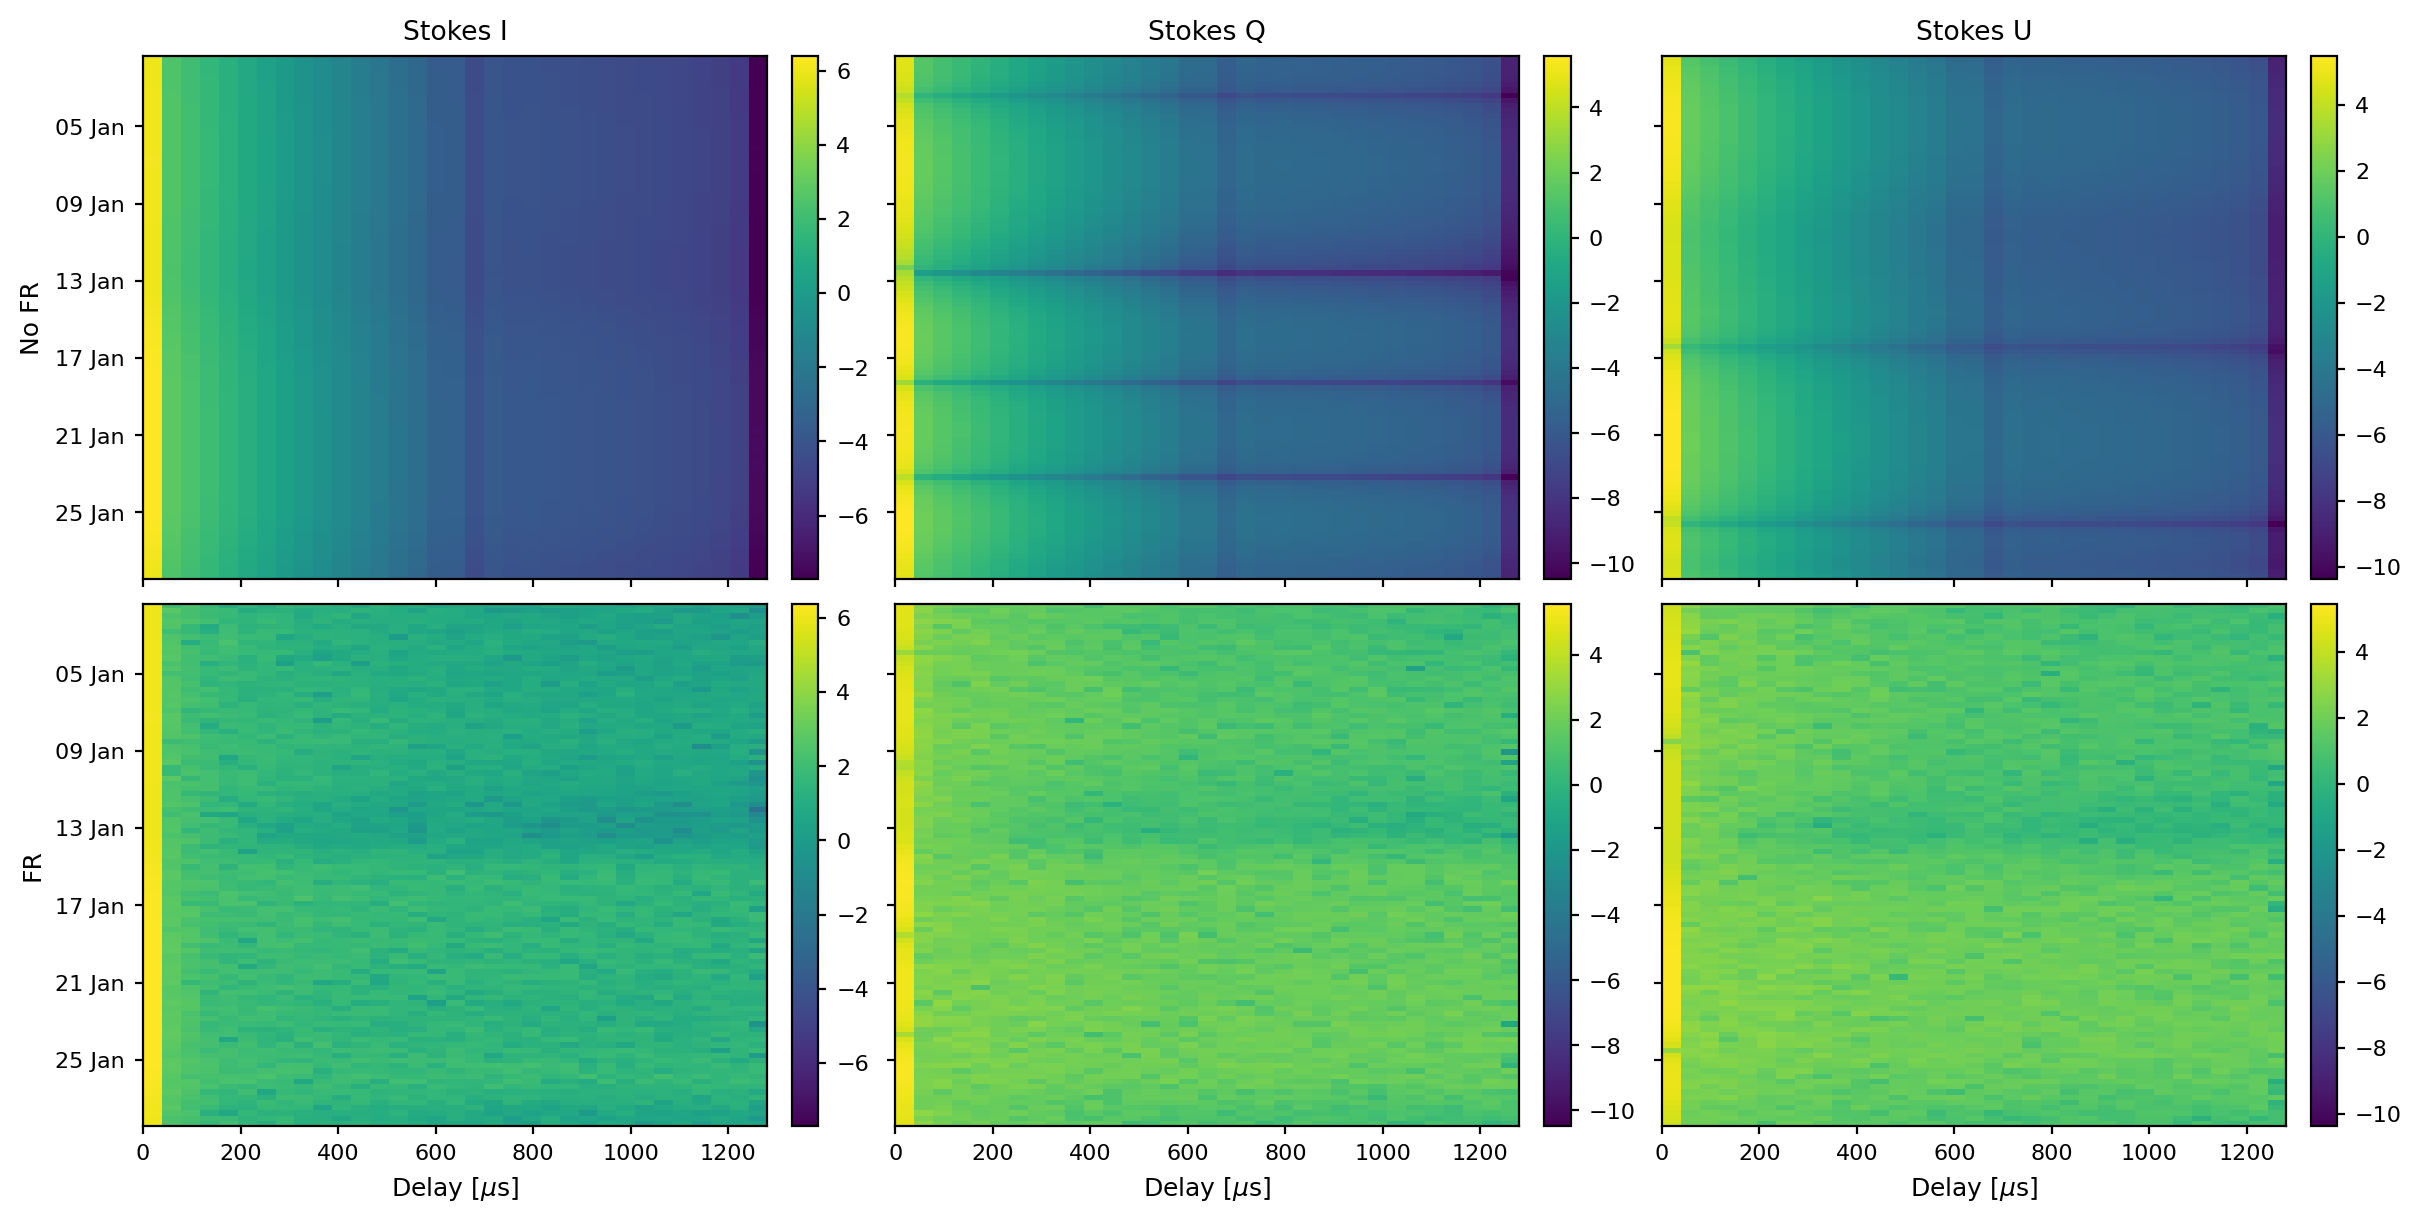

In [10]:
d = sims[30]
fz = d["freqs_zoom"]
df = fz[1] - fz[0]
tau = np.fft.rfftfreq(64, d=df)
extent_dly = [tau[0], tau[-1], mdates.date2num(times_dt[-1]),
              mdates.date2num(times_dt[0])]

fig, axs = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)

for col, s in enumerate(stokes):
    arr_noFR = d[f"p{s}_noFR_zoom"]
    arr_FR = d[f"p{s}_FR_zoom"]
    ft_noFR = np.log10(np.abs(np.fft.rfft(arr_noFR, axis=1)))
    ft_FR = np.log10(np.abs(np.fft.rfft(arr_FR, axis=1)))
    vmin = min(ft_noFR.min(), ft_FR.min())
    vmax = max(ft_noFR.max(), ft_FR.max())
    for row, (ft, label) in enumerate(zip([ft_noFR, ft_FR], row_labels)):
        ax = axs[row, col]
        im = ax.imshow(ft, aspect="auto", extent=extent_dly,
                       vmin=vmin, vmax=vmax)
        ax.yaxis_date()
        ax.yaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        if row == 0:
            ax.set_title(f"Stokes {s}")
        if col == 0:
            ax.set_ylabel(label)
        else:
            ax.set_yticklabels([])
        if row == 1:
            ax.set_xlabel(r"Delay [$\mu$s]")
        else:
            ax.set_xticklabels([])

plt.show()

## Plot 4 — Wide Bin vs Narrow Bin at 10, 30, 50 MHz

Galaxy-up snapshot comparing zoom-bin spectra to the single wide-bin value.

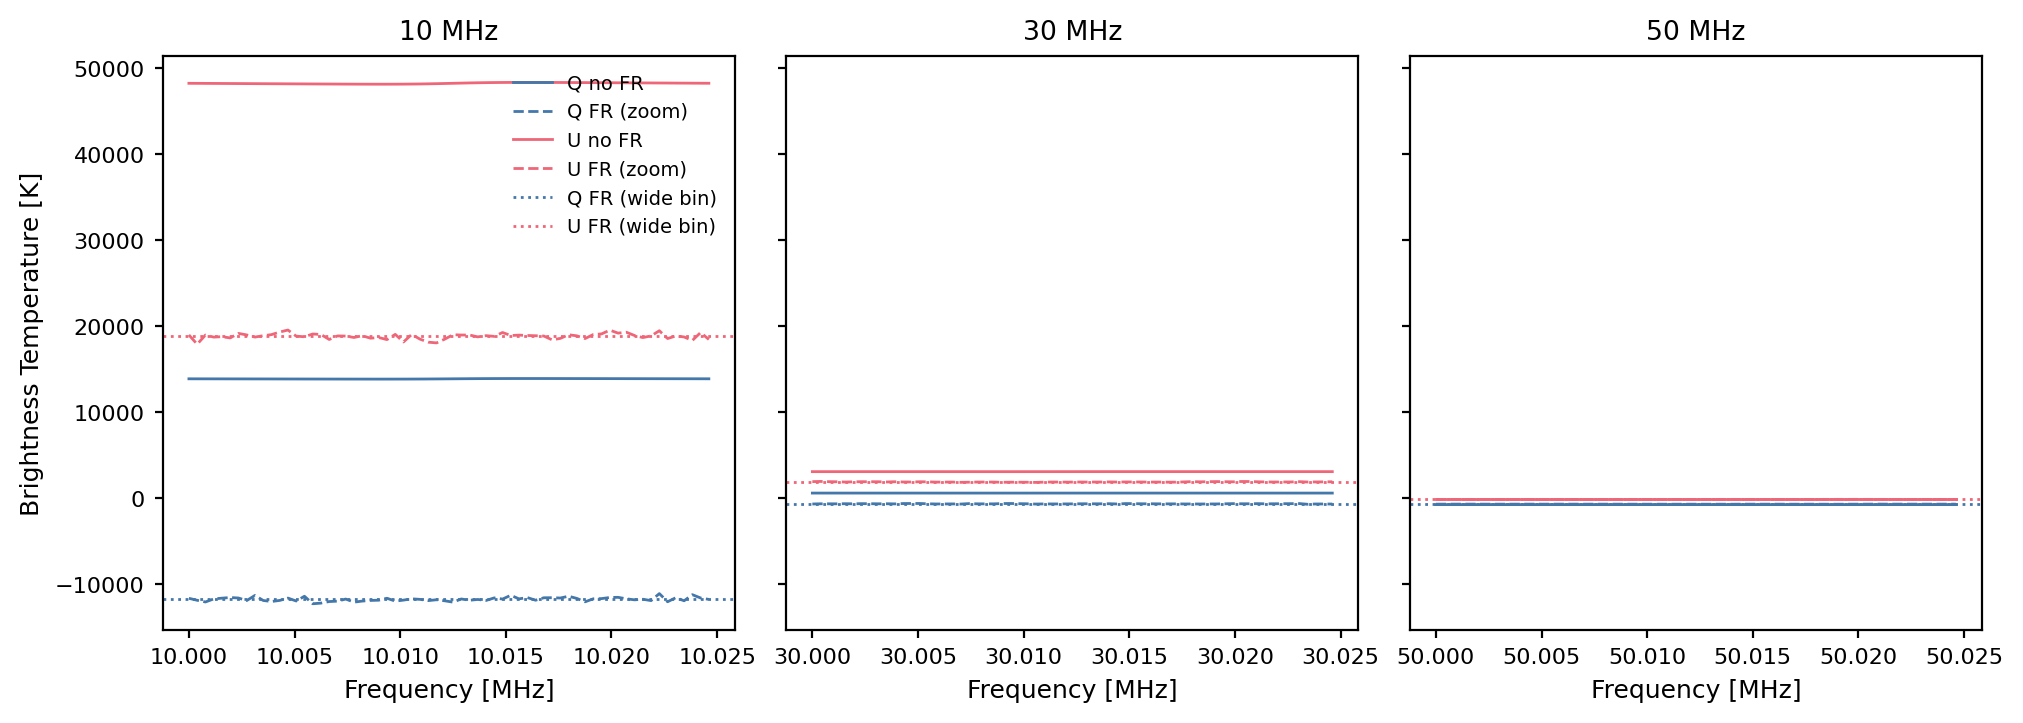

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5), constrained_layout=True,
                         sharey=True)

for i, freq in enumerate([10, 30, 50]):
    ax = axs[i]
    d = sims[freq]
    fz = d["freqs_zoom"]
    ig = int(d["i_gal"])

    # Zoom-bin spectra
    ax.plot(fz, d["pQ_noFR_zoom"][ig], color=BLUE, ls="-", lw=1,
            label="Q no FR")
    ax.plot(fz, d["pQ_FR_zoom"][ig], color=BLUE, ls="--", lw=1,
            label="Q FR (zoom)")
    ax.plot(fz, d["pU_noFR_zoom"][ig], color=RED, ls="-", lw=1,
            label="U no FR")
    ax.plot(fz, d["pU_FR_zoom"][ig], color=RED, ls="--", lw=1,
            label="U FR (zoom)")

    # Wide-bin horizontal lines (center bin = index 32)
    ax.axhline(d["pQ_FR_wconv"][0, 32], color=BLUE, ls=":", lw=1,
               label="Q FR (wide bin)")
    ax.axhline(d["pU_FR_wconv"][0, 32], color=RED, ls=":", lw=1,
               label="U FR (wide bin)")

    ax.set_title(f"{freq} MHz")
    ax.set_xlabel("Frequency [MHz]")

axs[0].set_ylabel("Brightness Temperature [K]")
axs[0].legend(frameon=False, fontsize=7)
plt.show()